# Synthetic SVXY: SVXY_synth-ONEx

#### **MScFE 690 Capstone -Group 17843**

**Authors**: Edgar NAVA-edgar.nava@grovwm.com & Celestin NYANDWI-celestinnyandwi48@gmail.com

The idea is to obtain a **semi-synthetic SVXY with a consistent -1x daily exposure** for our Capstone. We start with real SVXY daily closing prices to make a linear regression of its daily return respect to the index SPVIXSTR daily returns. Using the regression, we reconstruct February 6, 2018. We then extend the -1x series after SVXY changed its objective to -0.5x.

In our methodology we exclude February 5 from the regression, since is the date of volmageddon that distorted all market values. However, we use its actual closing values to estimate February 6.

Everything is read from and saved to the **current working directory**. If a library is missing, run `%pip install pandas numpy matplotlib openpyxl`.

This notebook creates one output file: `SVXY_synth-ONEx.csv`. The CSV contains `Date`, `Open`, `High`, `Low` and `Close`. We first calculate the semi-synthetic Close and then reconstruct Open, High and Low. From February 28, 2018 onward, we double their percentage movements measured from the previous actual Close, using the previous synthetic Close as the anchor. These are research synthetic prices derived from actual data.

This notebook requires the data of two CSV files in the same folder:

- SVXY_data.csv: daily SVXY data, including Date, Close, High, and Low.
- SPVIXSTR.xlsx: daily data of the S&P 500 VIX Short-Term Futures Total Return Index

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

DATA_DIR = Path.cwd()
SVXY_FILE = DATA_DIR / "SVXY_data.csv"
INDEX_FILE = DATA_DIR / "SPVIXSTR.xlsx"

FIT_END = pd.Timestamp("2018-02-02")
EVENT_BASE = pd.Timestamp("2018-02-05")
EVENT_DATE = pd.Timestamp("2018-02-06")
LAST_ONEX = pd.Timestamp("2018-02-27")
FIRST_HALFX = pd.Timestamp("2018-02-28")

missing = [p.name for p in [SVXY_FILE, INDEX_FILE] if not p.is_file()]
if missing:
    raise FileNotFoundError(
        f"Missing {missing} in {DATA_DIR}. Open this notebook in Data Retreived "
        "with SVXY_data.csv and SPVIXSTR.xlsx in the same working directory."
    )

plt.rcParams.update({
    "figure.figsize": (12, 5), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.20, "font.size": 10,
})
ACTUAL_COLOR = "#657786"
SYNTH_COLOR = "#087F8C"
EVENT_COLOR = "#BD5D36"

def sha256_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

input_hashes = {p.name: sha256_file(p) for p in [SVXY_FILE, INDEX_FILE]}

def validate_prices(series, label):
    if series.empty:
        raise ValueError(f"{label}: no observations.")
    if series.index.has_duplicates or series.index.isna().any():
        raise ValueError(f"{label}: missing or duplicate dates. Check the source.")
    values = series.to_numpy(dtype=float)
    if not np.isfinite(values).all() or (values <= 0).any():
        raise ValueError(f"{label}: missing, non-finite or non-positive prices.")

OHLC_COLUMNS = ["Open", "High", "Low", "Close"]

def validate_ohlc(frame, label):
    for column in OHLC_COLUMNS:
        validate_prices(frame[column], f"{label} {column}")
    invalid = (
        (frame["Low"] > frame[["Open", "Close"]].min(axis=1))
        | (frame["High"] < frame[["Open", "Close"]].max(axis=1))
        | (frame["High"] < frame["Low"])
    )
    if invalid.any():
        raise ValueError(f"{label}: inconsistent OHLC on {frame.index[invalid].tolist()}")

print("Working directory:", DATA_DIR)
print("Inputs found:", SVXY_FILE.name, "and", INDEX_FILE.name)

Working directory: /Users/edgarnava/Dropbox/AI/WorldQuant University/10 26:09 MScFE 690 Capstone Project/Python Codes/1 - Data Retreived and Synth SVXY
Inputs found: SVXY_data.csv and SPVIXSTR.xlsx


### 1. SVXY discontinuity and the change from -1x to -0.5x

SVXY originally targeted the inverse, **-1x**, of the daily return of a short-term VIX futures index. On **February 5, 2018**, the volatility shock known as *Volmageddon* caused a severe loss in inverse-volatility products. SVXY fell sharply after the regular market close, and trading was halted before the early session on February 6. The daily closing-price series therefore shows a very large drop between February 5 and February 6. This event and the trading disruption were documented by [NYSE Arca](https://www.nyse.com/publicdocs/nyse/markets/nyse-arca/rule-filings/filings/2018/NYSEArca-2018-12.pdf).

Later that month, ProShares changed SVXY's objective from -1x to **-0.5x**, effective at the close of February 27. Thus, the return from February 27 to February 28 is the first return in the new regime. See the [ProShares announcement filed with the SEC](https://www.sec.gov/Archives/edgar/data/1415311/000119312518059052/d503117dex991.htm).

The rationale for the "smooth" is to construct a consistent research scenario across the event and the change in leverage.

Now we load the SVXY OHLC data as supplied from Yahoo and plot the closing-price history, followed by a closer look at February 2018. We use the source columns exactly as provided. The model uses Close, and Section 5 uses the same day's Open, High and Low to reconstruct the complete synthetic bar.

SVXY: 3,759 prices, 2011-10-04 to 2026-09-16


,SVXY_actual_Close
Date,
2018-02-02,211.199997
2018-02-05,143.639999
2018-02-06,24.480000
2018-02-07,24.660000
2018-02-08,19.160000
2018-02-09,21.719999
2018-02-12,22.680000
2018-02-13,22.580000
2018-02-14,25.299999


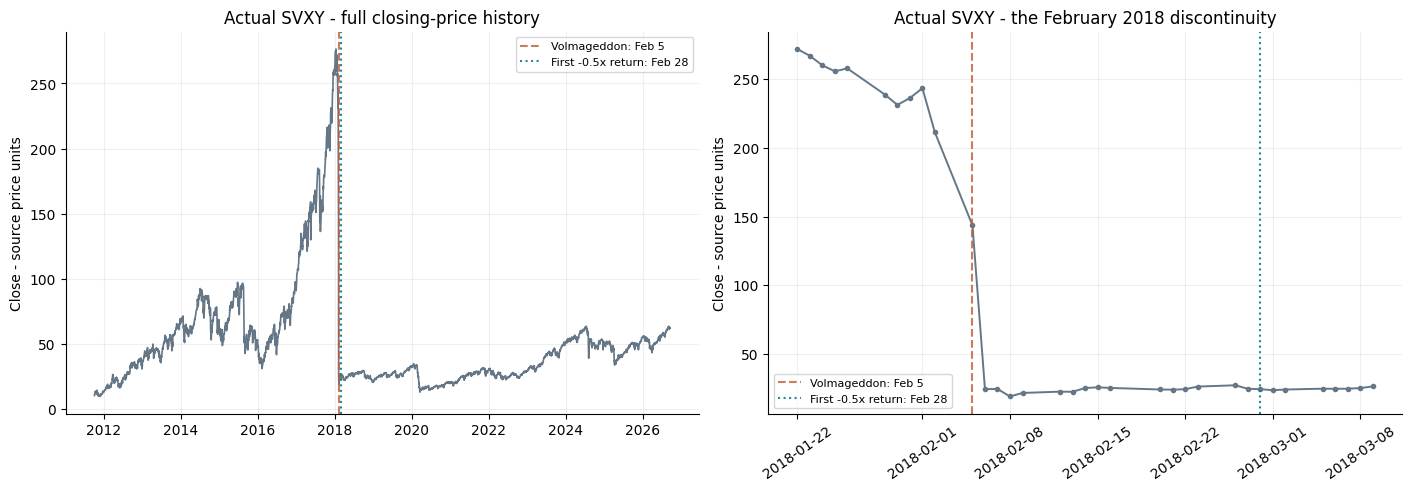

In [2]:
svxy_raw = pd.read_csv(SVXY_FILE)
svxy_raw.columns = svxy_raw.columns.str.strip()
if not {"Date", *OHLC_COLUMNS}.issubset(svxy_raw.columns):
    raise ValueError("SVXY_data.csv must contain Date, Open, High, Low and Close.")
svxy_raw["Date"] = pd.to_datetime(svxy_raw["Date"], errors="raise").dt.normalize()
for column in OHLC_COLUMNS:
    svxy_raw[column] = pd.to_numeric(svxy_raw[column], errors="raise")
actual_ohlc = svxy_raw.set_index("Date")[OHLC_COLUMNS].sort_index()
validate_ohlc(actual_ohlc, "Actual SVXY")
svxy = actual_ohlc["Close"].rename("SVXY_actual_Close")
for date in [FIT_END, EVENT_BASE, EVENT_DATE, LAST_ONEX, FIRST_HALFX]:
    if date not in svxy.index:
        raise ValueError(f"Required SVXY date missing: {date.date()}")

actual_returns = svxy.pct_change(fill_method=None)
print(f"SVXY: {len(svxy):,} prices, {svxy.index.min().date()} to {svxy.index.max().date()}")
display(svxy.loc["2018-02-02":"2018-03-02"].to_frame().round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
axes[0].plot(svxy.index, svxy, color=ACTUAL_COLOR, linewidth=1.2)
axes[0].set_title("Actual SVXY - full closing-price history")
event_window = svxy.loc["2018-01-22":"2018-03-09"]
axes[1].plot(event_window.index, event_window, marker="o", markersize=3,
             color=ACTUAL_COLOR, linewidth=1.4)
axes[1].set_title("Actual SVXY - the February 2018 discontinuity")
for ax in axes:
    ax.axvline(EVENT_BASE, color=EVENT_COLOR, linestyle="--", alpha=0.8,
               label="Volmageddon: Feb 5")
    ax.axvline(FIRST_HALFX, color=SYNTH_COLOR, linestyle=":", alpha=0.9,
               label="First -0.5x return: Feb 28")
    ax.set_ylabel("Close - source price units")
    ax.legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=35)
plt.show()

### 2. What is SPVIXSTR, and why do we use it?

SPVIXSTR is the total-return version of the **S&P 500 VIX Short-Term Futures Index**, as identified on the [S&P DJI index page](https://www.spglobal.com/spdji/en/indices/indicators/sp-500-vix-short-term-index-mcap/). It follows a rolling position in first- and second-month VIX futures, with approximately one month to maturity. The total-return calculation includes a collateral return. The construction is described in the [S&P VIX Futures Indices Methodology](https://www.spglobal.com/spdji/en/documents/methodologies/methodology-sp-vix-futures-indices.pdf).

We use it because SVXY's economic exposure comes from **VIX futures using the same rolling mechanism**, whereas spot VIX behavior may differ from the values of the index and the ETF. SPVIXSTR is therefore a more relevant explanatory series for this exercise. We estimate the relationship from the data instead of imposing a coefficient of exactly -1. Fees, tracking differences, the total-return convention and the timing of market closes can all contribute to deviations.

The SPVIXSTR data was **downloaded manually from Investing.com**, using the subscription account, and saved as `SPVIXSTR.xlsx`. The index is only needed through February 6, 2018 for the linear regression.An index discotinuity was detected on 2024-08-08, but it doesn't affect our calculations.

**The prevailing dates are those of SVXY.** We align the index prices to SVXY trading dates first, and only then calculate percentage changes. Index observations on dates when SVXY is not quoted do not create extra observations.

In [3]:
# The supplied Excel has its title in row 1 and column headers in row 2.
index_raw = pd.read_excel(INDEX_FILE, sheet_name="Sheet1", header=1, usecols="A:B")
index_raw.columns = index_raw.columns.str.strip()
if not {"Date", "Price"}.issubset(index_raw.columns):
    raise ValueError("SPVIXSTR.xlsx must have Date and Price in columns A:B, header row 2.")
index_raw["Date"] = pd.to_datetime(index_raw["Date"], errors="raise").dt.normalize()
index_raw["Price"] = pd.to_numeric(index_raw["Price"], errors="raise")
spvixstr = index_raw.set_index("Date")["Price"].sort_index().rename("SPVIXSTR_Price")
validate_prices(spvixstr, "SPVIXSTR")

index_source_returns = spvixstr.pct_change(fill_method=None)
large_index_jumps = index_source_returns.loc[index_source_returns.abs() > 5]
print(f"SPVIXSTR: {len(spvixstr):,} prices, {spvixstr.index.min().date()} to {spvixstr.index.max().date()}")
if not large_index_jumps.empty:
    print("Index level discontinuities above 500% (outside the model window if after Feb 6, 2018):")
    display(pd.DataFrame({"Price": spvixstr.loc[large_index_jumps.index],
                          "Mechanical_change_pct": 100 * large_index_jumps}))
    if (large_index_jumps.index <= EVENT_DATE).any():
        raise ValueError("An index discontinuity enters the model window. Resolve it first.")

aligned_prices = pd.DataFrame({"SVXY": svxy, "SPVIXSTR": spvixstr.reindex(svxy.index)})
common_start = max(svxy.index.min(), spvixstr.index.min())
needed_index = aligned_prices.loc[common_start:EVENT_DATE, "SPVIXSTR"]
if needed_index.isna().any():
    raise ValueError("SPVIXSTR is missing on an SVXY date needed for calibration or reconstruction.")

# Prices are aligned BEFORE percentage changes are computed.
aligned_returns = aligned_prices.pct_change(fill_method=None)
fit_data = aligned_returns.loc[:FIT_END].dropna(subset=["SVXY", "SPVIXSTR"]).copy()
if len(fit_data) < 30 or fit_data["SPVIXSTR"].std() == 0:
    raise ValueError("Insufficient usable variation for the regression.")
if EVENT_BASE in fit_data.index or EVENT_DATE in fit_data.index:
    raise AssertionError("Event dates must not enter the regression.")

print("Index dates outside the SVXY calendar:", len(spvixstr.index.difference(svxy.index)))
print("First common price:", common_start.date())
print(f"Regression returns: {fit_data.index.min().date()} to {fit_data.index.max().date()}, n = {len(fit_data):,}")
display(fit_data.head().mul(100).rename(columns={"SVXY":"deltaSVXY (%)", "SPVIXSTR":"deltaSPVIXSTR (%)"}))

SPVIXSTR: 3,452 prices, 2012-12-27 to 2026-09-18
Index level discontinuities above 500% (outside the model window if after Feb 6, 2018):


,Price,Mechanical_change_pct
Date,,
2024-08-08,17728.78,913754.639175


Index dates outside the SVXY calendar: 2
First common price: 2012-12-27
Regression returns: 2012-12-28 to 2018-02-02, n = 1,284


,deltaSVXY (%),deltaSPVIXSTR (%)
Date,,
2012-12-28,-5.152587,15.712018
2012-12-31,5.820531,-18.847955
2013-01-02,12.238357,-10.768713
2013-01-03,-0.830387,1.545772
2013-01-04,2.031577,-2.460213


#### The regression and the R²

By daily variation, or delta, we mean a **simple percentage change**:

$$\Delta SVXY_t = P_t/P_{t-1}-1,\qquad \Delta SPVIXSTR_t = I_t/I_{t-1}-1.$$

We estimate the following ordinary least-squares regression, including an intercept:

$$\Delta SVXY_t=\alpha+\beta\,\Delta SPVIXSTR_t+\varepsilon_t.$$

We exclude February 5, 2018. The last return used in the fit is February 2. Although SVXY starts in October 2011, the supplied SPVIXSTR file starts on **December 27, 2012**. Therefore, the first usable common daily return is December 28, 2012.

With the supplied data, we obtained **1,284 daily returns and R² of approximately 88.87%**. R² measures the fraction of in-sample variation in SVXY returns explained by this linear relationship. As an additional check, we also estimate using data through 2016 and evaluate the relationship on 2017, without refitting on 2017.

deltaSVXY = 0.000145873991 + (-0.865500732768) * deltaSPVIXSTR
R² = 0.88866917 (88.8669%)
RMSE = 1.2630 percentage points; observations = 1,284
2017 holdout: R² = 0.873182, RMSE = 1.0758 percentage points, n = 251


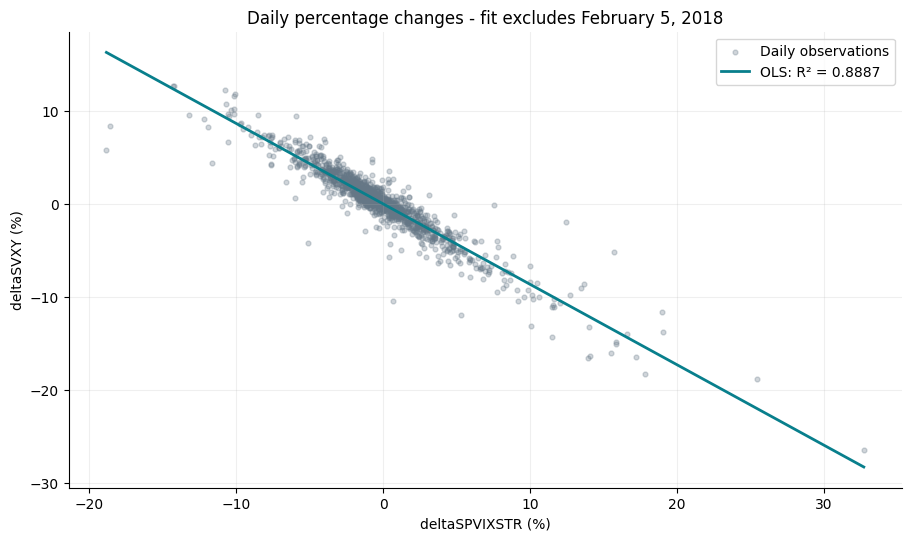

In [4]:
def fit_daily_ols(data):
    x = data["SPVIXSTR"].to_numpy(dtype=float)
    y = data["SVXY"].to_numpy(dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    alpha_, beta_ = np.linalg.lstsq(design, y, rcond=None)[0]
    fitted_ = alpha_ + beta_ * x
    sst = np.sum((y - y.mean()) ** 2)
    if sst <= 0:
        raise ValueError("SVXY returns have no variation.")
    r2_ = 1 - np.sum((y - fitted_) ** 2) / sst
    rmse_ = np.sqrt(np.mean((y - fitted_) ** 2))
    return float(alpha_), float(beta_), float(r2_), float(rmse_), fitted_

alpha, beta, r_squared, rmse, fitted = fit_daily_ols(fit_data)
fit_data["Fitted_SVXY_return"] = fitted
print(f"deltaSVXY = {alpha:.12f} + ({beta:.12f}) * deltaSPVIXSTR")
print(f"R² = {r_squared:.8f} ({100*r_squared:.4f}%)")
print(f"RMSE = {100*rmse:.4f} percentage points; observations = {len(fit_data):,}")

train = fit_data.loc[:"2016-12-31"]
test = fit_data.loc["2017-01-01":"2017-12-31"]
holdout = None
if len(train) >= 30 and len(test) >= 2:
    a_train, b_train, _, _, _ = fit_daily_ols(train)
    test_prediction = a_train + b_train * test["SPVIXSTR"]
    test_sst = ((test["SVXY"] - test["SVXY"].mean()) ** 2).sum()
    if test_sst <= 0:
        raise ValueError("The holdout returns have no variation.")
    holdout = {
        "training_observations": len(train), "test_observations": len(test),
        "test_year": 2017,
        "r_squared": float(1 - ((test["SVXY"] - test_prediction) ** 2).sum() / test_sst),
        "rmse": float(np.sqrt(((test["SVXY"] - test_prediction) ** 2).mean())),
    }
    print(f"2017 holdout: R² = {holdout['r_squared']:.6f}, "
          f"RMSE = {100*holdout['rmse']:.4f} percentage points, n = {len(test)}")

fig, ax = plt.subplots(figsize=(9, 5.3), constrained_layout=True)
ax.scatter(100*fit_data["SPVIXSTR"], 100*fit_data["SVXY"], s=12,
           alpha=0.30, color=ACTUAL_COLOR, label="Daily observations")
x_line = np.linspace(fit_data["SPVIXSTR"].min(), fit_data["SPVIXSTR"].max(), 200)
ax.plot(100*x_line, 100*(alpha + beta*x_line), color=SYNTH_COLOR,
        linewidth=2, label=f"OLS: R² = {r_squared:.4f}")
ax.set(xlabel="deltaSPVIXSTR (%)", ylabel="deltaSVXY (%)",
       title="Daily percentage changes - fit excludes February 5, 2018")
ax.legend()
plt.show()

### 3. Estimating the SVXY close on February 6 and the correction coefficient

So far, we have a daily relationship estimated without February 5. Now we use the actual SPVIXSTR change **from February 5 to February 6**, and insert it into that same regression:

$$\widehat r_6=\alpha+\beta\left(\frac{I_6}{I_5}-1\right),\qquad
\widehat P_6=P^{actual}_5(1+\widehat r_6).$$

The correction factor is:

$$corr\_f=\frac{\widehat P_6}{P^{actual}_6}.$$

We then multiply each actual SVXY closing price from **February 6 through February 27, inclusive**, by `corr_f`. Before February 6 we keep the actual SVXY closing prices.

The rationale is to replace the February 5-to-6 return with the return implied by the pre-event relationship. A constant multiplier preserves every actual daily return from February 7 through February 27. February 5's actual decline remains in the series; this construction does not erase the whole episode.

For reference, the supplied data should give a hypothetical February 6 close near **175.920985**, compared with the actual **24.48**, and `corr_f` near **7.186315**.

,Calculation,Value
0,SPVIXSTR close Feb 5,110.370000
1,SPVIXSTR close Feb 6,81.730000
2,SPVIXSTR change Feb 6 (%),-25.949080
3,Estimated SVXY change Feb 6 (%),22.473535
4,Actual SVXY close Feb 5,143.639999
5,Actual SVXY close Feb 6,24.480000
6,Estimated SVXY close Feb 6,175.920985
7,corr_f,7.186315
8,Corrected SVXY close Feb 27,178.076887


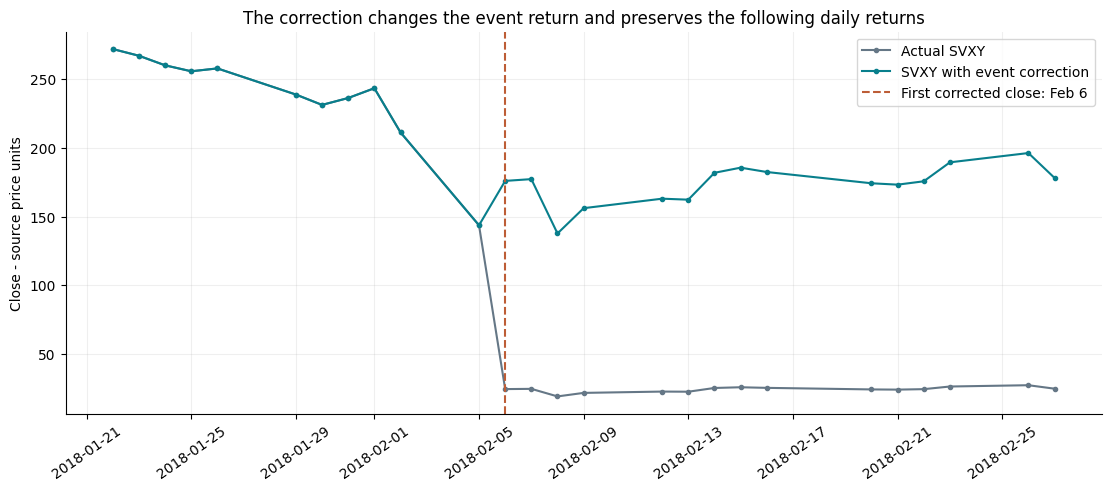

In [5]:
index_return_feb6 = float(aligned_returns.loc[EVENT_DATE, "SPVIXSTR"])
estimated_return_feb6 = float(alpha + beta * index_return_feb6)
if not np.isfinite(estimated_return_feb6) or estimated_return_feb6 <= -1:
    raise ValueError("The model implies a non-positive February 6 close.")

estimated_close_feb6 = float(svxy.loc[EVENT_BASE] * (1 + estimated_return_feb6))
corr_f = estimated_close_feb6 / float(svxy.loc[EVENT_DATE])
if not np.isfinite(corr_f) or corr_f <= 0:
    raise ValueError("Invalid correction factor.")

event_adjusted = svxy.loc[:LAST_ONEX].copy().rename("SVXY_event_adjusted_Close")
event_adjusted.loc[EVENT_DATE:LAST_ONEX] *= corr_f

event_summary = pd.DataFrame({
    "Calculation": ["SPVIXSTR close Feb 5", "SPVIXSTR close Feb 6",
                    "SPVIXSTR change Feb 6 (%)", "Estimated SVXY change Feb 6 (%)",
                    "Actual SVXY close Feb 5", "Actual SVXY close Feb 6",
                    "Estimated SVXY close Feb 6", "corr_f",
                    "Corrected SVXY close Feb 27"],
    "Value": [aligned_prices.loc[EVENT_BASE, "SPVIXSTR"],
              aligned_prices.loc[EVENT_DATE, "SPVIXSTR"],
              100*index_return_feb6, 100*estimated_return_feb6,
              svxy.loc[EVENT_BASE], svxy.loc[EVENT_DATE],
              estimated_close_feb6, corr_f, event_adjusted.loc[LAST_ONEX]],
})
display(event_summary.round({"Value": 9}))

fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
observed_window = svxy.loc["2018-01-22":LAST_ONEX]
adjusted_window = event_adjusted.loc["2018-01-22":LAST_ONEX]
ax.plot(observed_window.index, observed_window, color=ACTUAL_COLOR, marker="o",
        markersize=3, label="Actual SVXY")
ax.plot(adjusted_window.index, adjusted_window, color=SYNTH_COLOR, marker="o",
        markersize=3, label="SVXY with event correction")
ax.axvline(EVENT_DATE, color=EVENT_COLOR, linestyle="--", label="First corrected close: Feb 6")
ax.set(title="The correction changes the event return and preserves the following daily returns",
       ylabel="Close - source price units")
ax.tick_params(axis="x", rotation=35)
ax.legend()
plt.show()

### 4. Extending the -1x series after February 27

From February 28 onward, real SVXY has a -0.5x daily objective. To extend our -1x scenario, we take **twice the actual daily percentage variation**, and recompute the closing values by daily compounding. For example, an actual return of -2% becomes a synthetic return of -4%; it does not mean doubling the price.

**The correction factor must continue after February 27.** We use the **already corrected February 27 close** as the starting value:

$$S_{27}=corr\_f\,P^{actual}_{27}.$$

Then, for every trading date starting on February 28:

$$S_t=S_{t-1}\left[1+2\left(\frac{P^{actual}_t}{P^{actual}_{t-1}}-1\right)\right].$$

Equivalently, the whole post-February-27 path is:

$$S_t=corr\_f\,P^{actual}_{27}\prod_{u=\mathrm{Feb\ 28}}^t(1+2r^{actual}_u).$$

Therefore `corr_f` is applied **once to the entire reconstructed path**.
 
Multiplying the later actual prices by `corr_f` alone would retain -0.5x daily returns, so we also need the doubled returns.

This gives us continuity in the construction: the February 28 return is exactly twice its actual return, with no extra jump caused by switching formulas. There can still be a normal daily price movement at the boundary.

The doubling rule is our approximation to constant -1x exposure. It also doubles any fixed fees and tracking errors in actual SVXY returns; but since the principal cost component (management fee) is proportional to the price, the obtained values are a good approximation.

In [6]:
post_returns = actual_returns.loc[FIRST_HALFX:].copy()
if post_returns.empty or post_returns.isna().any():
    raise ValueError("Missing SVXY returns in the post-change period.")
post_growth = 1 + 2 * post_returns
invalid_growth = post_growth.loc[(~np.isfinite(post_growth)) | (post_growth <= 0)]
if not invalid_growth.empty:
    raise ValueError(f"Doubling produces invalid daily growth on: {invalid_growth.index.tolist()}")

synthetic = pd.Series(index=svxy.index, dtype=float, name="SVXY_synth-ONEx")
synthetic.loc[:LAST_ONEX] = event_adjusted

# corr_f is already included in this anchor. Do not multiply it again.
corrected_anchor = float(event_adjusted.loc[LAST_ONEX])
synthetic.loc[FIRST_HALFX:] = corrected_anchor * post_growth.cumprod()
validate_prices(synthetic, "SVXY_synth-ONEx")
synthetic_returns = synthetic.pct_change(fill_method=None)

boundary_dates = pd.to_datetime(["2018-02-26", "2018-02-27", "2018-02-28", "2018-03-01"])
boundary = pd.DataFrame({
    "Actual_Close": svxy, "Synthetic_Close": synthetic,
    "Actual_daily_change_pct": 100*actual_returns,
    "Synthetic_daily_change_pct": 100*synthetic_returns,
}).loc[boundary_dates]
display(boundary.round(6))
print(f"Corrected Feb 27 anchor: {corrected_anchor:.9f}")
print(f"Feb 28 synthetic close: {synthetic.loc[FIRST_HALFX]:.9f}")
print(f"Smallest doubled daily return after Feb 27: {100*(2*post_returns).min():.4f}%")

,Actual_Close,Synthetic_Close,Actual_daily_change_pct,Synthetic_daily_change_pct
2018-02-26,27.299999,196.186386,3.566001,3.566001
2018-02-27,24.780001,178.076887,-9.230762,-9.230762
2018-02-28,24.459999,173.477617,-1.291372,-2.582744
2018-03-01,23.740000,163.264721,-2.943577,-5.887155


Corrected Feb 27 anchor: 178.076886737
Feb 28 synthetic close: 173.477616551
Smallest doubled daily return after Feb 27: -42.8686%


#### The final SVXY_synth-ONEx and the boundary checks

We now have one series made of three clearly defined parts:

| Closing dates | Construction |
|---|---|
| Through February 5, 2018 | Actual SVXY closing prices |
| February 6-27, 2018 | Actual SVXY closing prices multiplied by `corr_f` |
| From February 28, 2018 | Corrected February 27 close, compounded using twice each subsequent actual SVXY daily return |

We check these identities before saving the file. The final comparison includes the full history and a closer look at the transition, so we can see both the event correction and the change in daily exposure. A logarithmic scale is used for the full history so that changes at different price levels remain visible.

All construction checks passed, including February 27 -> February 28.


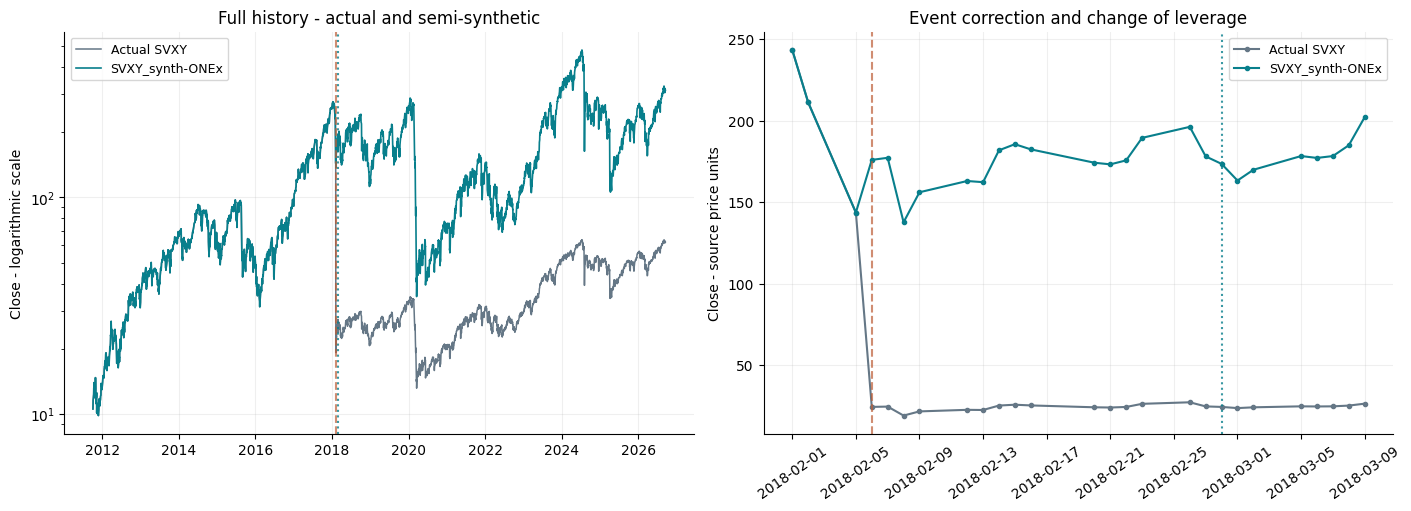

In [7]:
# These checks test the economic boundaries of the construction.
pd.testing.assert_index_equal(synthetic.index, svxy.index)
np.testing.assert_allclose(synthetic.loc[:EVENT_BASE], svxy.loc[:EVENT_BASE], rtol=1e-12)
np.testing.assert_allclose(synthetic.loc[EVENT_DATE], estimated_close_feb6, rtol=1e-12)
np.testing.assert_allclose(synthetic_returns.loc[EVENT_DATE], estimated_return_feb6, atol=1e-12)
np.testing.assert_allclose(synthetic.loc[EVENT_DATE:LAST_ONEX] / svxy.loc[EVENT_DATE:LAST_ONEX],
                           corr_f, rtol=1e-12)
np.testing.assert_allclose(synthetic_returns.loc["2018-02-07":LAST_ONEX],
                           actual_returns.loc["2018-02-07":LAST_ONEX], atol=1e-12)
np.testing.assert_allclose(synthetic_returns.loc[FIRST_HALFX:], 2*post_returns, atol=1e-12)
np.testing.assert_allclose(synthetic.loc[FIRST_HALFX] / synthetic.loc[LAST_ONEX] - 1,
                           2*actual_returns.loc[FIRST_HALFX], atol=1e-12)

# Independent equivalent formula: apply corr_f once to the uncorrected compounded path.
uncorrected_compounded_path = svxy.loc[LAST_ONEX] * post_growth.cumprod()
np.testing.assert_allclose(synthetic.loc[FIRST_HALFX:], corr_f*uncorrected_compounded_path, rtol=1e-12)
print("All construction checks passed, including February 27 -> February 28.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].plot(svxy.index, svxy, color=ACTUAL_COLOR, linewidth=1.1, label="Actual SVXY")
axes[0].plot(synthetic.index, synthetic, color=SYNTH_COLOR, linewidth=1.2, label="SVXY_synth-ONEx")
axes[0].set_yscale("log")
axes[0].set(title="Full history - actual and semi-synthetic", ylabel="Close - logarithmic scale")
zoom = pd.DataFrame({"Actual SVXY": svxy, "SVXY_synth-ONEx": synthetic}).loc["2018-02-01":"2018-03-09"]
axes[1].plot(zoom.index, zoom["Actual SVXY"], color=ACTUAL_COLOR, marker="o", markersize=3, label="Actual SVXY")
axes[1].plot(zoom.index, zoom["SVXY_synth-ONEx"], color=SYNTH_COLOR, marker="o", markersize=3, label="SVXY_synth-ONEx")
axes[1].set(title="Event correction and change of leverage", ylabel="Close - source price units")
for ax in axes:
    ax.axvline(EVENT_DATE, color=EVENT_COLOR, linestyle="--", alpha=0.7)
    ax.axvline(FIRST_HALFX, color=SYNTH_COLOR, linestyle=":", alpha=0.8)
    ax.legend(fontsize=9)
axes[1].tick_params(axis="x", rotation=35)
plt.show()

### 5. Reconstruct Open, High and Low from the previous Close

So far, we have calculated the new Close. The idea now is to extend the same daily doubling rule to Open, High and Low. We use the **previous trading day's Close as the common reference for all four prices**.

The reconstruction has three periods:

| Dates | OHLC construction |
|---|---|
| Through February 5, 2018 | Keep the actual Open, High, Low and Close |
| February 6-27, 2018 | Multiply the actual OHLC by `corr_f` |
| From February 28, 2018 | Double each price's percentage movement from the previous actual Close, anchored to the previous synthetic Close |

For every date from February 28 onward, let $X_t$ represent Open, High, Low or Close. We calculate:

$$r^X_t=\frac{X^{actual}_t}{C^{actual}_{t-1}}-1,$$

$$X^{synth}_t=C^{synth}_{t-1}\left(1+2r^X_t\right)
=C^{synth}_{t-1}\left[1+2\left(\frac{X^{actual}_t}{C^{actual}_{t-1}}-1\right)\right].$$

Here, $t-1$ means the previous date in the SVXY trading calendar. For $X=C$, this is exactly the closing-price formula used in Section 4. We keep that previously calculated Close. On February 28, the anchor is the corrected February 27 close, so `corr_f` is already included.

The rationale is to reconstruct the whole candle with the same change of daily exposure. The opening gap, the candle body and the high-low range all double **when measured as a fraction of the previous Close**. This is different from preserving O/C, H/C and L/C, or doubling distances relative to the current day's Close.

For example, if the previous actual Close is 100 and today's O/H/L/C are 102/110/90/105, their movements from that previous Close are +2%/+10%/-10%/+5%. The synthetic prices are then 1.04/1.20/0.80/1.10 times the previous synthetic Close.

The code checks all four reconstructed prices, including the Low, for positive values before saving the result.

In [8]:
# Preserve the existing construction through February 27.
# In February 6-27 this rescaling is equivalent to actual OHLC * corr_f.
synthetic_ohlc = pd.DataFrame(index=svxy.index, columns=OHLC_COLUMNS, dtype=float)
before_change = actual_ohlc.loc[:LAST_ONEX]
synthetic_ohlc.loc[:LAST_ONEX] = before_change.div(
    before_change["Close"], axis=0
).mul(synthetic.loc[:LAST_ONEX], axis=0)
synthetic_ohlc.loc[:EVENT_BASE] = actual_ohlc.loc[:EVENT_BASE]

# From February 28, use the same previous-close reference for O, H, L and C.
post_actual_ohlc = actual_ohlc.loc[FIRST_HALFX:]
previous_actual_close = svxy.shift(1).loc[post_actual_ohlc.index]
previous_synthetic_close = synthetic.shift(1).loc[post_actual_ohlc.index]
actual_ohlc_movements = post_actual_ohlc.div(previous_actual_close, axis=0) - 1
doubled_ohlc_growth = 1 + 2 * actual_ohlc_movements
invalid_ohlc_growth = (
    ~np.isfinite(doubled_ohlc_growth).all(axis=1)
    | (doubled_ohlc_growth <= 0).any(axis=1)
)
if invalid_ohlc_growth.any():
    raise ValueError(
        "Doubling produces a non-positive or invalid intraday price on: "
        f"{doubled_ohlc_growth.index[invalid_ohlc_growth].tolist()}"
    )

post_synthetic_ohlc = doubled_ohlc_growth.mul(previous_synthetic_close, axis=0)
np.testing.assert_allclose(
    post_synthetic_ohlc["Close"], synthetic.loc[FIRST_HALFX:], rtol=1e-12, atol=1e-12
)
# Preserve exact price ties with Close when equivalent formulas differ by rounding.
post_synthetic_ohlc["Close"] = synthetic.loc[FIRST_HALFX:]
for column in ["Open", "High", "Low"]:
    same_as_close = post_actual_ohlc[column].eq(post_actual_ohlc["Close"])
    post_synthetic_ohlc.loc[same_as_close, column] = post_synthetic_ohlc.loc[same_as_close, "Close"]
synthetic_ohlc.loc[FIRST_HALFX:] = post_synthetic_ohlc
# Retain the exact previously calculated Close, including floating-point precision.
synthetic_ohlc["Close"] = synthetic

validate_ohlc(synthetic_ohlc, "Synthetic SVXY")
pd.testing.assert_index_equal(synthetic_ohlc.index, actual_ohlc.index)
np.testing.assert_array_equal(synthetic_ohlc["Close"], synthetic)
np.testing.assert_array_equal(synthetic_ohlc.loc[:EVENT_BASE], actual_ohlc.loc[:EVENT_BASE])
np.testing.assert_allclose(
    synthetic_ohlc.loc[EVENT_DATE:LAST_ONEX],
    actual_ohlc.loc[EVENT_DATE:LAST_ONEX] * corr_f, rtol=1e-12,
)

# Check every OHLC movement against the previous closing-price anchor.
synthetic_ohlc_movements = synthetic_ohlc.loc[FIRST_HALFX:].div(
    previous_synthetic_close, axis=0
) - 1
np.testing.assert_allclose(
    synthetic_ohlc_movements, 2 * actual_ohlc_movements, rtol=1e-12, atol=1e-12
)
synthetic_range = (post_synthetic_ohlc["High"] - post_synthetic_ohlc["Low"]) / previous_synthetic_close
actual_range = (post_actual_ohlc["High"] - post_actual_ohlc["Low"]) / previous_actual_close
np.testing.assert_allclose(synthetic_range, 2 * actual_range, rtol=1e-12, atol=1e-12)

example_dates = pd.to_datetime(["2018-02-05", "2018-02-06", "2018-02-27", "2018-02-28"])
print("Original OHLC:")
display(actual_ohlc.loc[example_dates].round(6))
print("Reconstructed OHLC:")
display(synthetic_ohlc.loc[example_dates].round(6))
print("February 28 movements from each series' previous Close:")
display(pd.DataFrame({
    "Actual_movement_pct": 100 * actual_ohlc_movements.loc[FIRST_HALFX],
    "Synthetic_movement_pct": 100 * synthetic_ohlc_movements.loc[FIRST_HALFX],
}).round(6))
print(f"OHLC checks passed for all {len(synthetic_ohlc):,} dates; the Close methodology is unchanged.")

Original OHLC:


,Open,High,Low,Close
2018-02-05,200.000000,214.380005,140.300003,143.639999
2018-02-06,23.400000,24.580000,22.219999,24.480000
2018-02-27,26.940001,27.260000,24.540001,24.780001
2018-02-28,25.500000,25.540001,24.459999,24.459999


Reconstructed OHLC:


,Open,High,Low,Close
2018-02-05,200.000000,214.380005,140.300003,143.639999
2018-02-06,168.159765,176.639617,159.679907,175.920985
2018-02-27,193.599327,195.898940,176.352171,178.076887
2018-02-28,188.425166,189.000085,173.477617,173.477617


February 28 movements from each series' previous Close:


,Actual_movement_pct,Synthetic_movement_pct
Open,2.905565,5.811130
High,3.066989,6.133979
Low,-1.291372,-2.582744
Close,-1.291372,-2.582744


OHLC checks passed for all 3,759 dates; the Close methodology is unchanged.


#### How does our new SVXY synthetic 1x look?

Now we plot **SVXY_synth-ONEx on its own**, using the complete history of the Close on a linear scale. The blue segment shows SVXY through February 27, 2018, including the existing event correction from February 6 through February 27. The teal segment extends the series at -1x from February 28, connected to the corrected February 27 Close. The dotted vertical line marks the start of this extension. The chart also identifies the latest closing value and its date.

These are the same closing prices included in the final OHLC file.

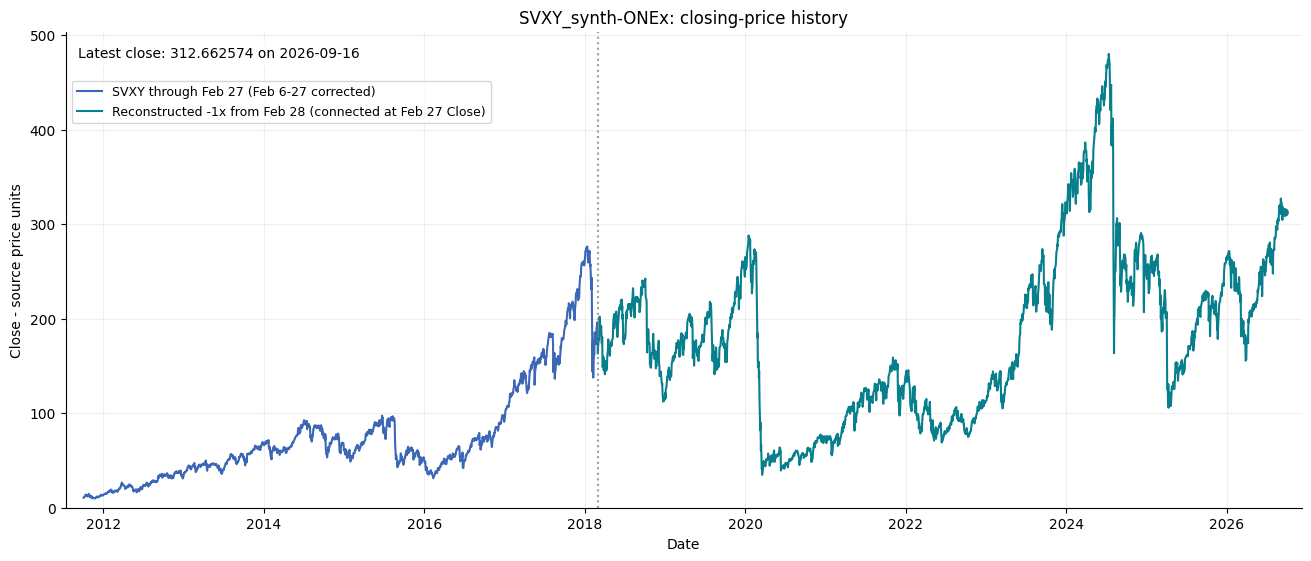

In [9]:
chart_close = synthetic_ohlc["Close"]
fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
ax.plot(chart_close.loc[:LAST_ONEX].index, chart_close.loc[:LAST_ONEX],
        color="#3B67B6", linewidth=1.5,
        label="SVXY through Feb 27 (Feb 6-27 corrected)")
# Include the corrected Feb 27 anchor so the two segments connect.
ax.plot(chart_close.loc[LAST_ONEX:].index, chart_close.loc[LAST_ONEX:],
        color="#087F8C", linewidth=1.5,
        label="Reconstructed -1x from Feb 28 (connected at Feb 27 Close)")
last_date, last_close = chart_close.index[-1], float(chart_close.iloc[-1])
ax.scatter([last_date], [last_close], color="#087F8C", s=28, zorder=3)
ax.axvline(FIRST_HALFX, color=ACTUAL_COLOR, linestyle=":", alpha=0.7)
ax.set(title="SVXY_synth-ONEx: closing-price history",
       xlabel="Date", ylabel="Close - source price units")
ax.set_ylim(bottom=0)
ax.margins(x=0.015, y=0.08)
ax.text(0.01, 0.97, f"Latest close: {last_close:.6f} on {last_date:%Y-%m-%d}",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85})
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.91), fontsize=9)
plt.show()

### 6. Save the final file to disk

Now we save **SVXY_synth-ONEx.csv** in the same working directory. 

In [10]:
csv_path = DATA_DIR / "SVXY_synth-ONEx.csv"

output = synthetic_ohlc.copy()
output.index.name = "Date"
output.to_csv(csv_path, date_format="%Y-%m-%d", float_format="%.12f")

# Check the saved file itself, including calendar and first/last rows.
saved = pd.read_csv(csv_path, parse_dates=["Date"]).set_index("Date")
pd.testing.assert_index_equal(saved.index, output.index)
if saved.columns.tolist() != OHLC_COLUMNS:
    raise AssertionError("Unexpected output columns.")
np.testing.assert_allclose(saved, output, rtol=1e-12, atol=1e-10)
validate_ohlc(saved, "Saved synthetic SVXY")
for p in [SVXY_FILE, INDEX_FILE]:
    if sha256_file(p) != input_hashes[p.name]:
        raise AssertionError(f"Input file changed while the notebook was running: {p.name}")

print(f"Done: {len(saved):,} OHLC bars, {saved.index.min().date()} to {saved.index.max().date()}.")
print(f"R² = {100*r_squared:.4f}% | corr_f = {corr_f:.9f}")
display(pd.concat([saved.head(3), saved.tail(3)]).round(6))

Done: 3,759 OHLC bars, 2011-10-04 to 2026-09-16.
R² = 88.8669% | corr_f = 7.186314752


,Open,High,Low,Close
Date,,,,
2011-10-04,9.872500,10.525000,9.825000,10.525000
2011-10-05,10.882500,11.410000,10.862500,11.347500
2011-10-06,11.357500,11.582500,11.200000,11.582500
2026-09-14,308.799556,318.117200,308.191872,315.686535
2026-09-15,317.098316,318.106718,311.249448,315.384019
2026-09-16,319.113382,319.818929,304.699849,312.662574


### Data and reference links:

- [Investing.com - SPVIXSTR historical data](https://www.investing.com/indices/sp-500-vix-short-term-futures-tri-historical-data): manually downloaded input.
- [S&P DJI - S&P 500 VIX Short-Term Futures Index](https://www.spglobal.com/spdji/en/indices/indicators/sp-500-vix-short-term-index-mcap/): index identity and return versions.
- [S&P VIX Futures Indices Methodology](https://www.spglobal.com/spdji/en/documents/methodologies/methodology-sp-vix-futures-indices.pdf): rolling futures and return calculations.
- [ProShares announcement, February 26, 2018](https://www.sec.gov/Archives/edgar/data/1415311/000119312518059052/d503117dex991.htm): change effective at the close of February 27.
- [NYSE Arca filing, February 6, 2018](https://www.nyse.com/publicdocs/nyse/markets/nyse-arca/rule-filings/filings/2018/NYSEArca-2018-12.pdf): event-related market disruption. Historical quoted share prices in that document use the contemporaneous share scale and should not be substituted directly for the supplied Yahoo closing-price series.